# ORF307 Homework 8 {-} 


Due: Friday, May 1, 2026 9:00 pm ET

- Please export your code with output as pdf.
- If there is any additional answers, please combine them as **ONE** pdf file before submitting to the Gradescope.

# Q1 A small integer programming problem {-}

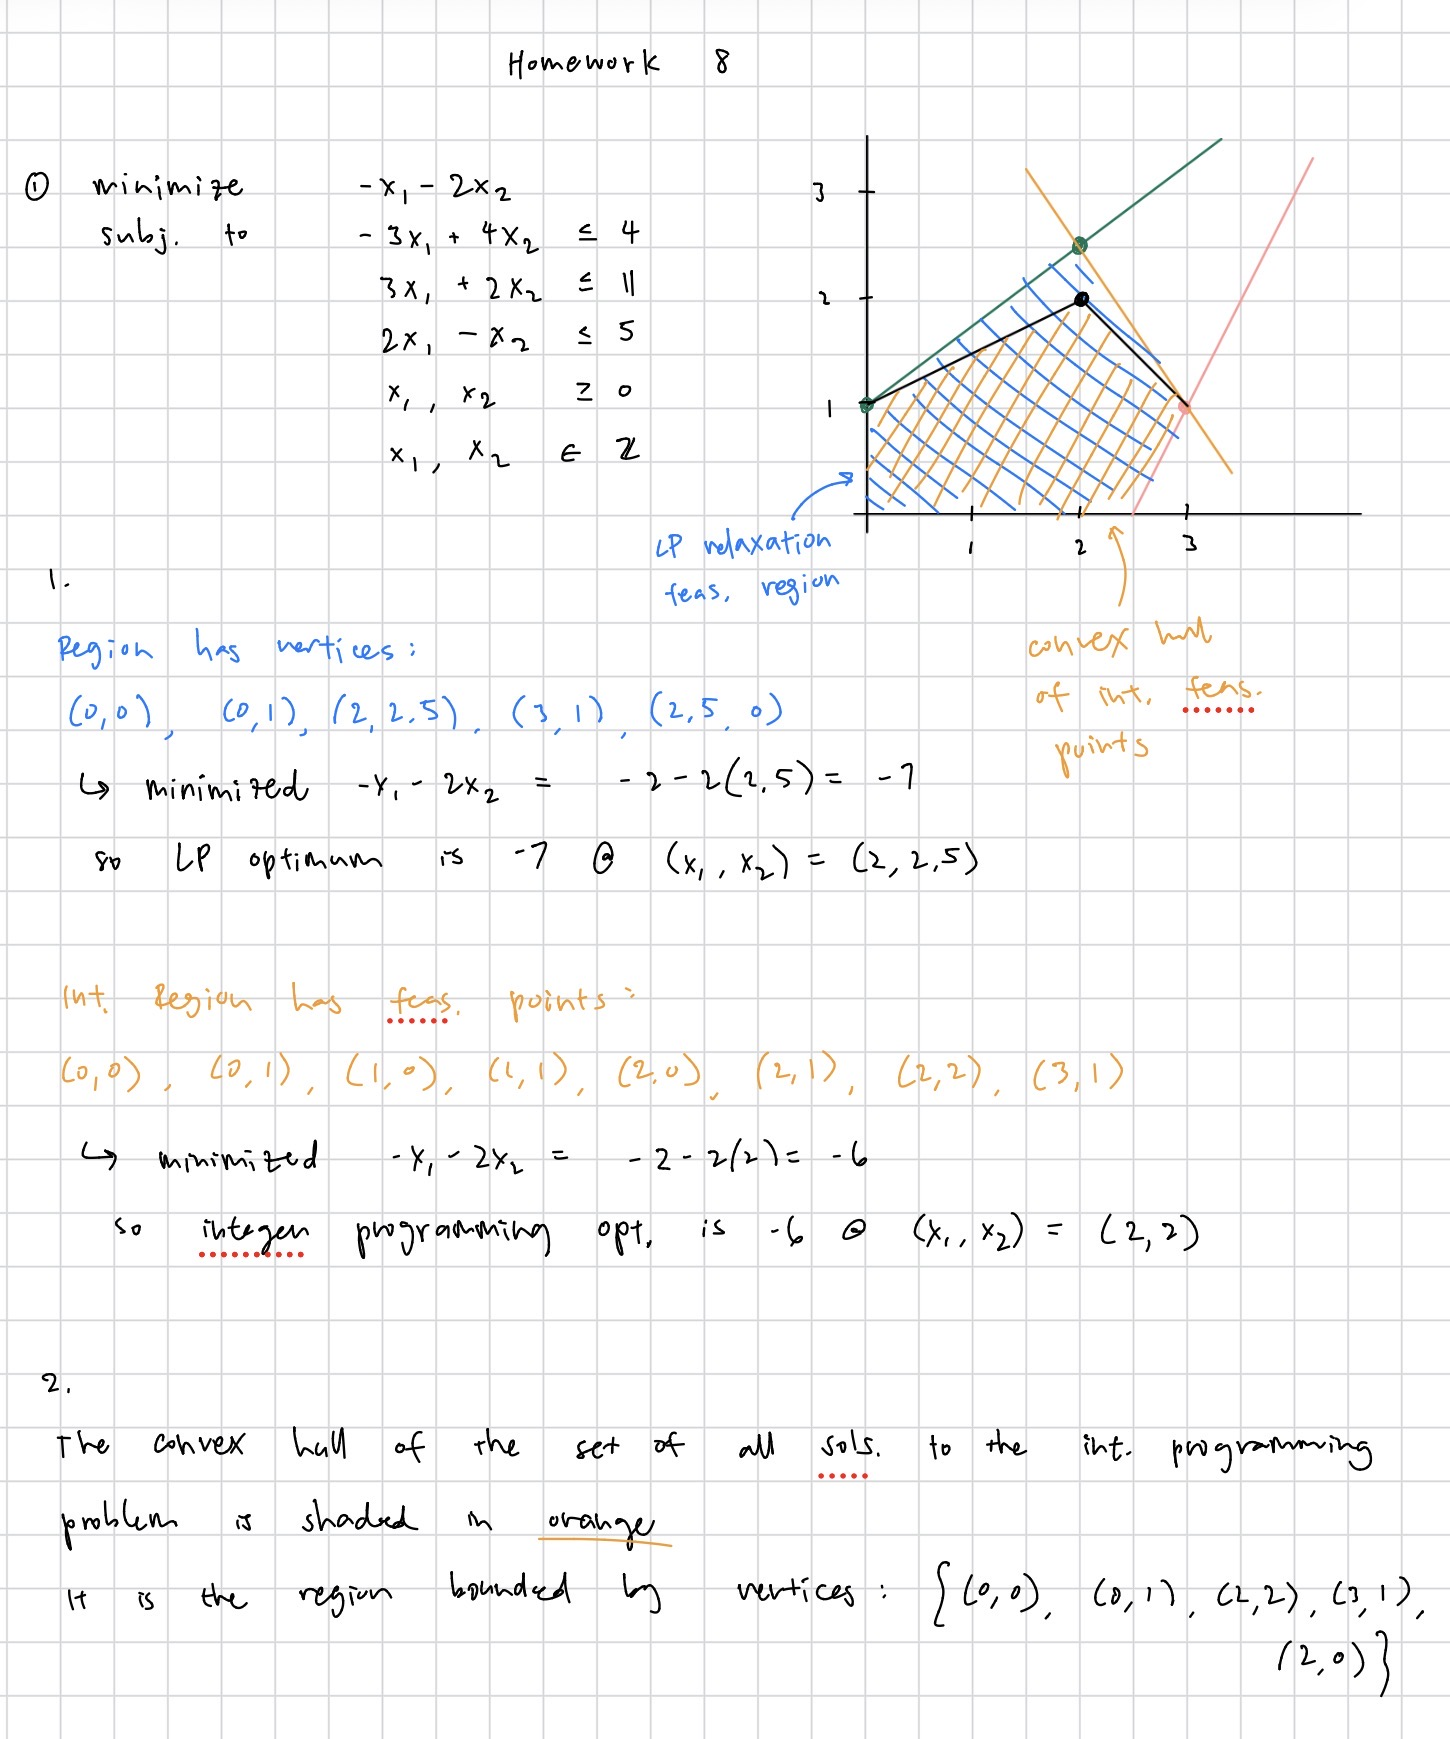

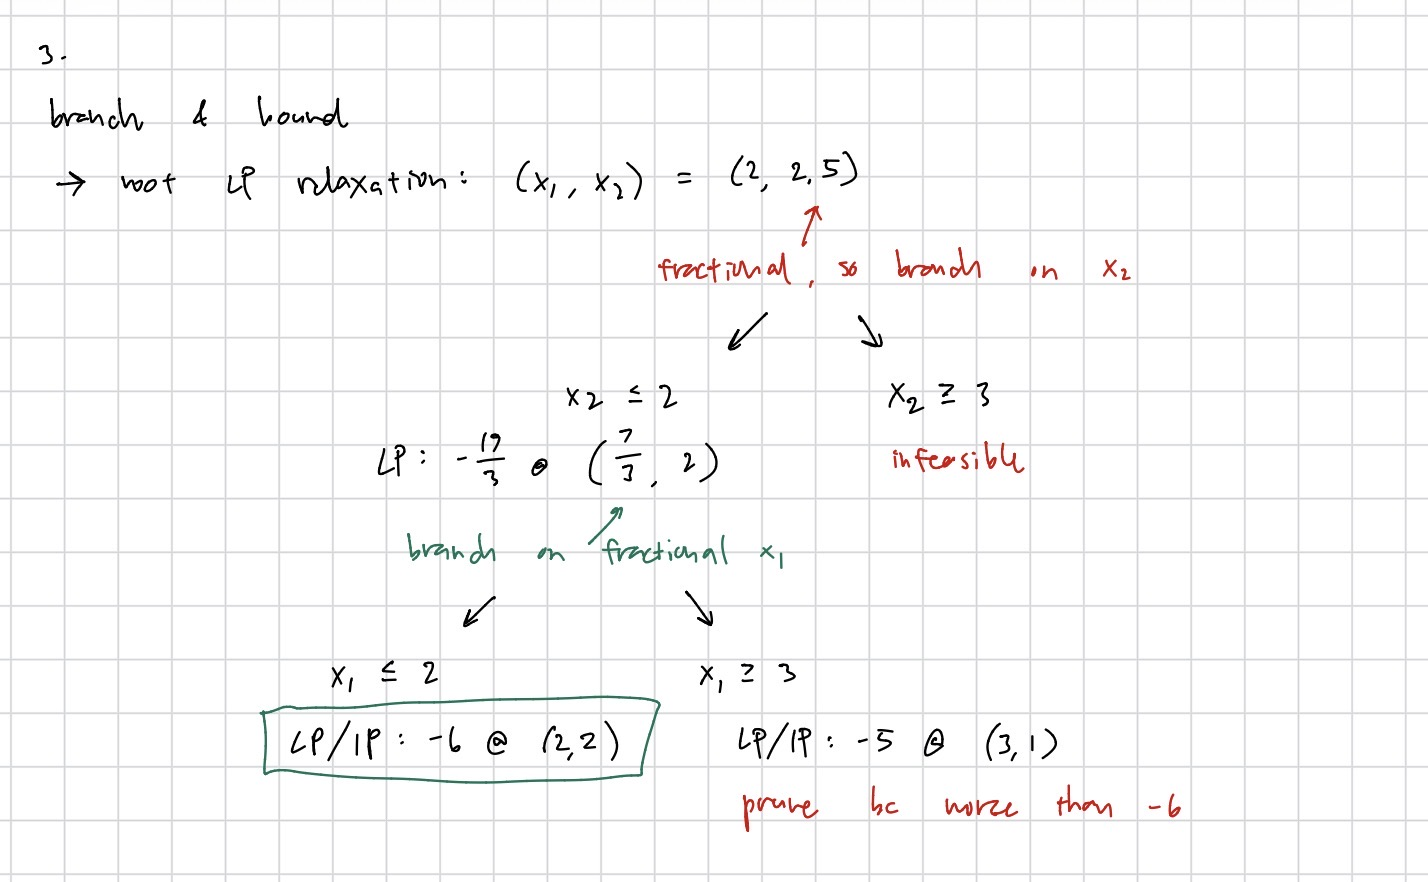

In [1]:
from IPython.display import Image, display 
display(Image("1ab.jpg", width=600)) 
display(Image("1c.jpg", width=600))

# Q2 Planning to move {-}

It is the end of the semester and you might be planning to change accommodation. Moving is complicated and you want to use some integer programming tricks to make your life easier. 

You rented a truck with capacity $Q$ and you bought $m$ boxes. Each box $i$ has size $b_i$ for $i=1,\dots,m$. You have $n$ items to move of size $a_j$ for $j=1,\dots,n$. 

1. Formulate your packing problem as an integer programming problem to determine if your move is doable with the truck and the boxes you have.
2. Given the data below, is your move feasible? If so, what is the minimum number of boxes you need to use? Answer using the solver `cp.SCIPY`.

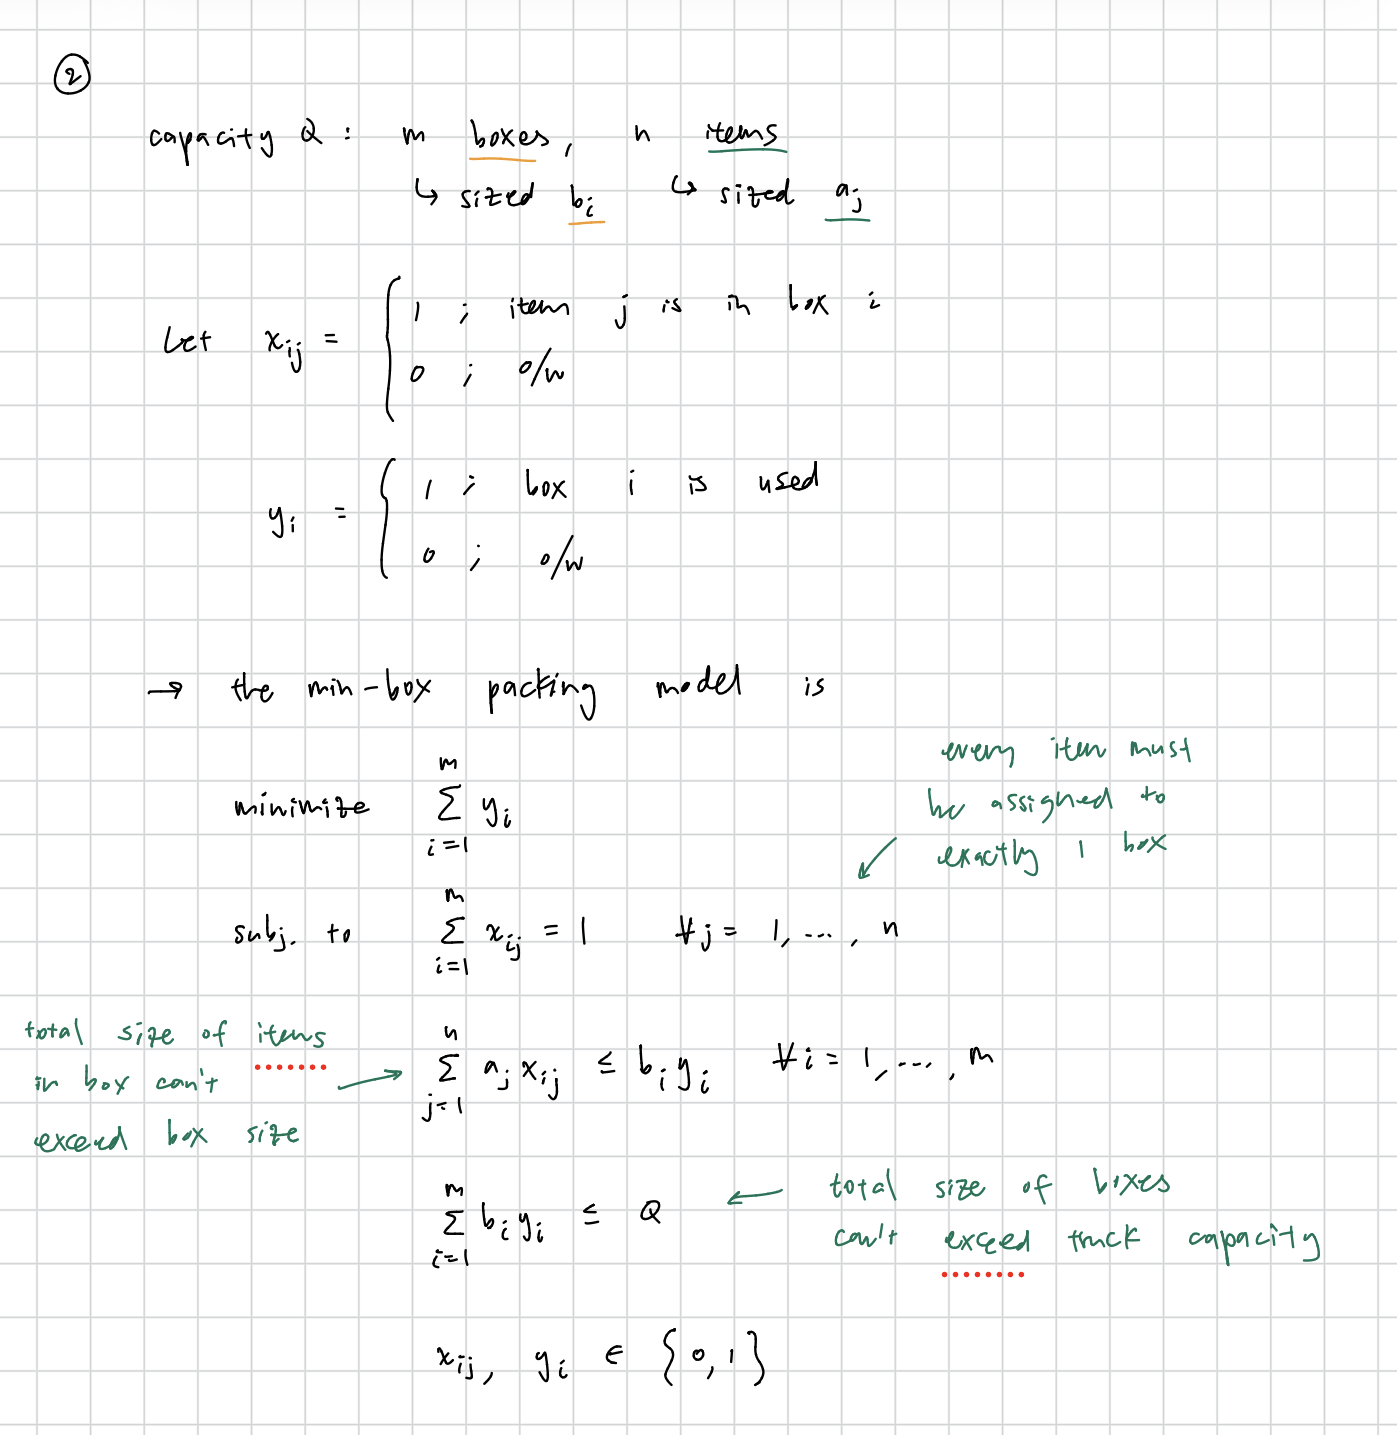

In [14]:
display(Image("2a.png", width=600))

In [7]:
import cvxpy as cp
import numpy as np

n = 30
m = 10
Q = 100

a = np.array([4, 3, 1, 2, 2,
              5, 4, 2, 4, 2,
              4, 1, 5, 2, 1,
              3, 5, 3, 3, 3,
              4, 5, 5, 2, 3,
              3, 3, 2, 2, 2])

b = np.array([7, 19, 10, 14, 10, 12, 13, 10, 15, 14])

# x[i,j] = 1 if item j goes in box i
x = cp.Variable((m, n), boolean=True)

# y[i] = 1 if box i is used
y = cp.Variable(m, boolean=True)

constraints = []

# every item must be assigned to exactly 1 box
constraints.append(cp.sum(x, axis=0) == 1)

# total size of items in box can't exceed box size
constraints.append(x @ a <= cp.multiply(b, y))

# total size of boxes can't exceed truck capacity
constraints.append(b @ y <= Q)



objective = cp.Minimize(cp.sum(y))

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCIPY)

print("Status:", prob.status)
print("Minimum number of boxes:", prob.value)
print("Used boxes:", np.where(y.value > 0.5)[0] + 1)
print("Total truck capacity used:", b @ np.round(y.value))

Status: optimal
Minimum number of boxes: 7.0
Used boxes: [ 1  2  4  6  7  9 10]
Total truck capacity used: 94.0


# Q3 Robust production planning {-}

You manage a firm selling two products, with integer production quantities $x_1, x_2$, subject to the following linear production constraints,
\begin{equation}
\begin{array}{ll}
\text{maximize} & c_1x_1 + c_2x_2\\
 \text{subject to} &  x_1 + x_2 \leq 15\\
 & 2x_1 + x_2 \leq 22\\
 & x_1, x_2 \geq 0\\
  & x_1, x_2 \in \mathbb{Z}.
\end{array}
\end{equation}
You wish to maximize your profit, $c_1x_1 + c_2x_2$, but the per-unit profits $c_1, c_2$ are uncertain.

The true profit vector $c$ is only known to lie in the box uncertainty set,
\begin{equation}
\mathcal{U} = \bigl\{\, c \in \mathbf{R}^2 : |c_i - \bar{c}_i| \leq \hat{c}_i,~i=1,2\bigr\},
\end{equation}
where $\hat{c}$ specifies the half-width of the box in each coordinate, and $\bar{c}$ the nominal/mean profits.
This uncertainty set is equivalent to the infinity-norm uncertainty set,
\begin{equation}
\mathcal{U} = \bigl\{\, c = Mu + a: \| u \|_\infty \leq 1\},
\end{equation}
where $M \in \mathbf{R}^{2\times 2}$, and $a \in \mathbf{R}^2$.

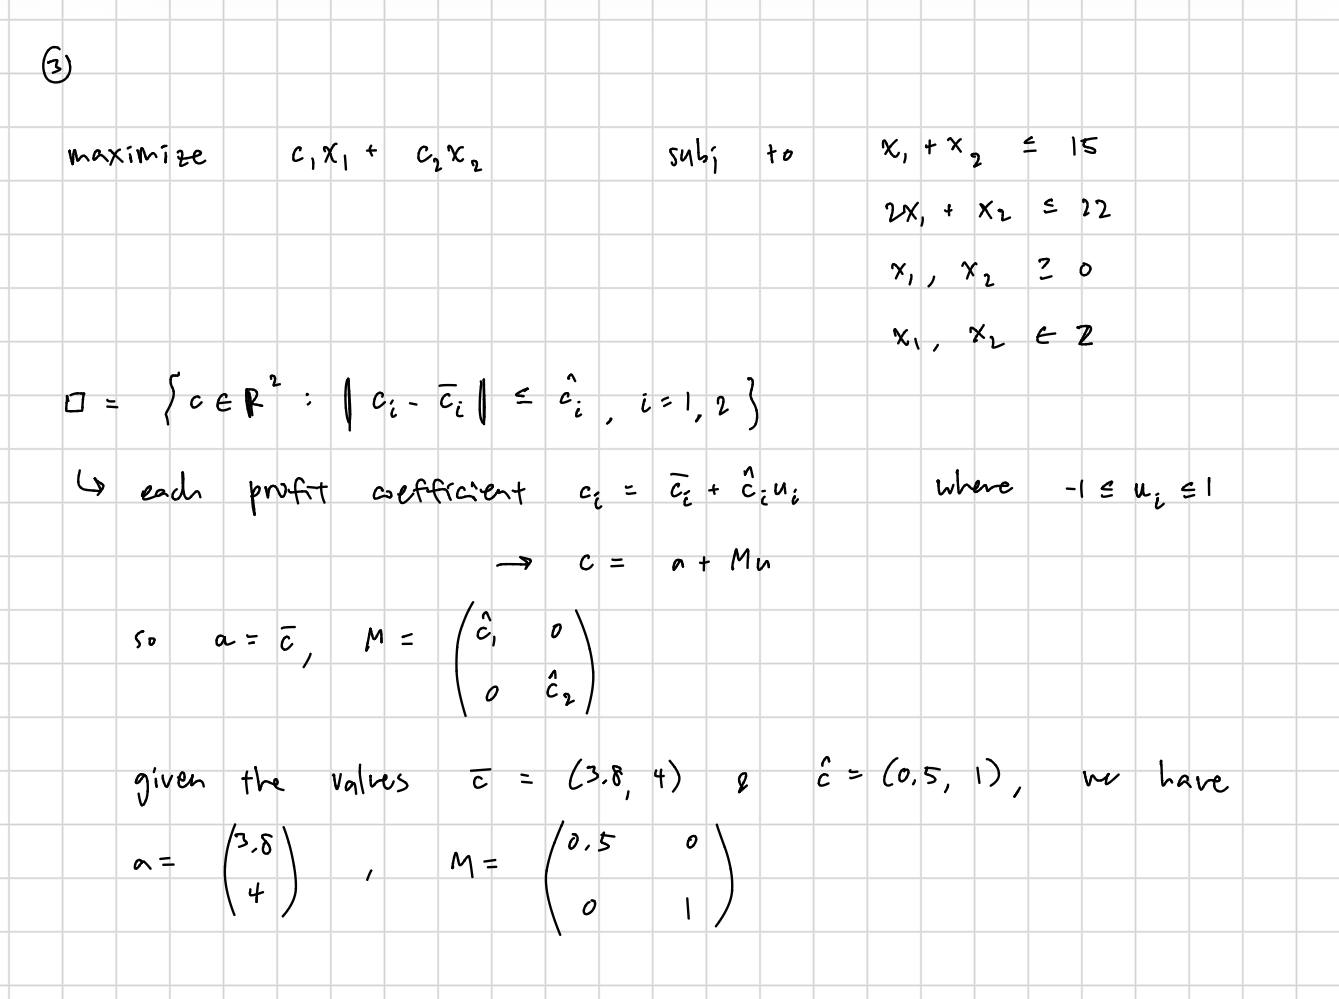

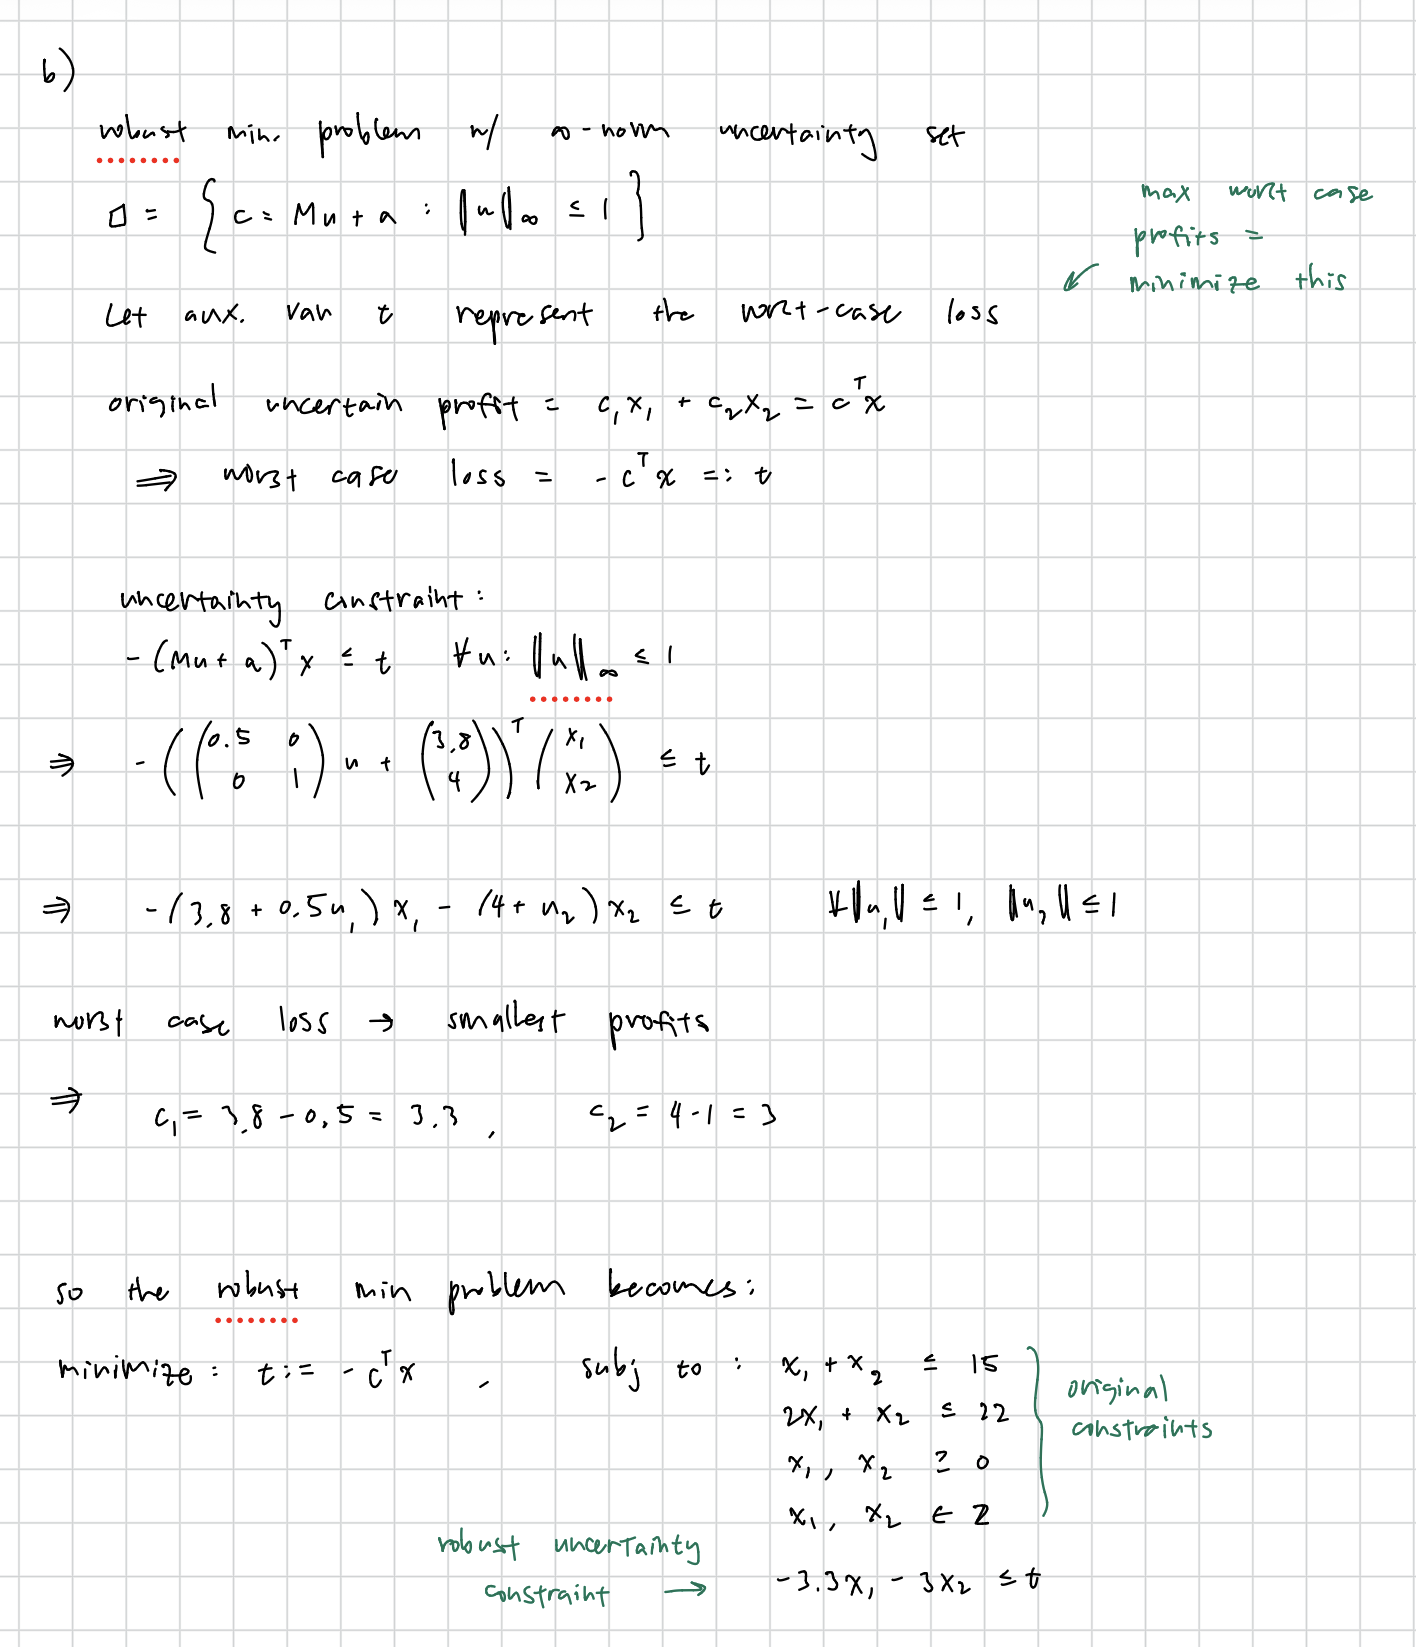

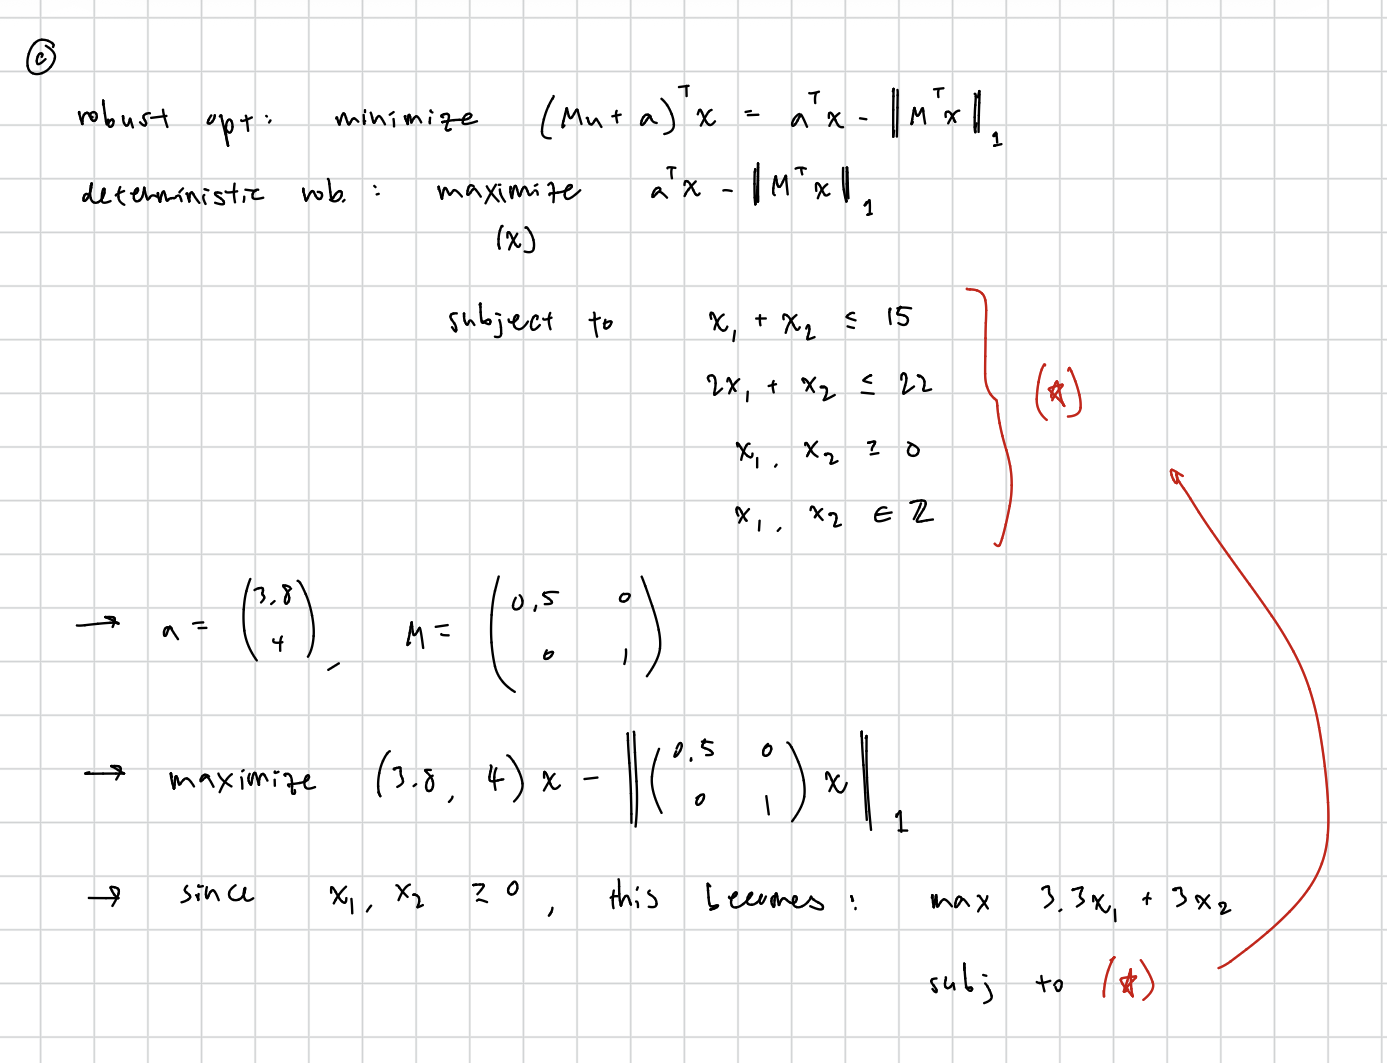

In [17]:
display(Image("3a.png", width=600))
display(Image("3b.png", width=600))
display(Image("3c.png", width=600))

In [18]:
import cvxpy as cp
import numpy as np

a = np.array([3.8, 4.0])
M = np.array([[0.5, 0.0],
              [0.0, 1.0]])

x = cp.Variable(2, integer=True)

objective = cp.Maximize(a @ x - cp.norm(M.T @ x, 1))

constraints = [
    x[0] + x[1] <= 15,
    2*x[0] + x[1] <= 22,
    x >= 0
]

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCIPY)

print("Status:", prob.status)
print("Robust optimal worst-case profit:", prob.value)
print("x:", np.round(x.value))

Status: optimal
Robust optimal worst-case profit: 47.099999999999994
x: [7. 8.]


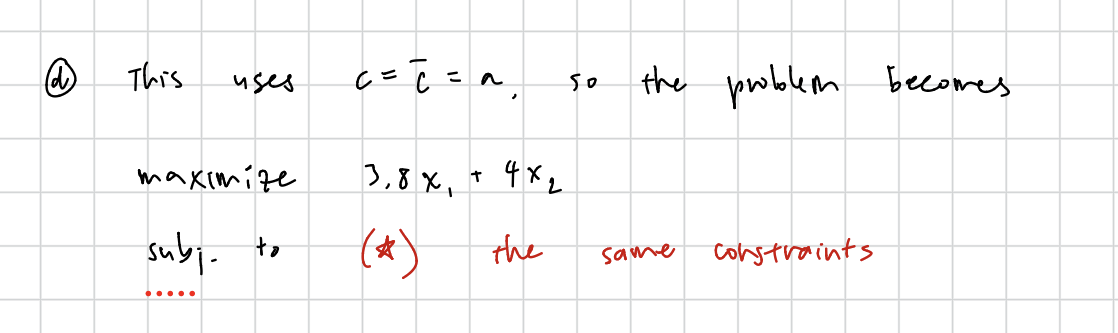

In [19]:
display(Image("3d.png", width=600))

In [20]:
x_nom = cp.Variable(2, integer=True)

objective_nom = cp.Maximize(a @ x_nom)

constraints_nom = [
    x_nom[0] + x_nom[1] <= 15,
    2*x_nom[0] + x_nom[1] <= 22,
    x_nom >= 0
]

prob_nom = cp.Problem(objective_nom, constraints_nom)
prob_nom.solve(solver=cp.SCIPY)

print("Status:", prob_nom.status)
print("Nominal optimal profit:", prob_nom.value)
print("x:", np.round(x_nom.value))

Status: optimal
Nominal optimal profit: 60.0
x: [-0. 15.]


so, the robust solution is: 
x = (7, 8) with worst-case profit 47.1

the nominal solution is:
x = (0, 15) with nominal profit 60

however, under worst-case profits, the nominal solution only earns 3.3(0) + 3(15) = 45

so, 
the nominal solution has a higher nominal profit, but the robust solution is better under the worst-case. 

Robust solution x = (7,8)
Average profit: 58.44349297827592
Standard deviation: 5.13992322593276
Worst-case dataset profit: 48.20996618486927

Nominal solution x = (0,15)
Average profit: 59.66863832356986
Standard deviation: 8.816674420336595
Worst-case dataset profit: 45.01637894690987


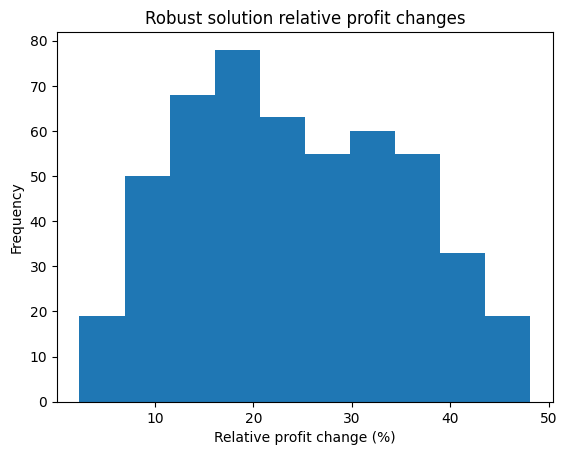

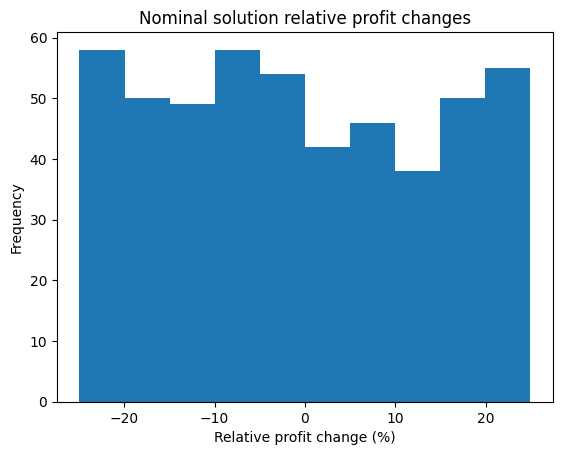

In [21]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

c_bar = np.array([3.8, 4])
c_hat = np.array([0.5, 1.0])

D = np.random.uniform(c_bar - c_hat, c_bar + c_hat, size=(500, 2))

x_robust = np.array([7, 8])
x_nominal = np.array([0, 15])

pstar_robust = 47.1
pstar_nominal = 60.0

# profits for each sample
profits_robust = D @ x_robust
profits_nominal = D @ x_nominal

print("Robust solution x = (7,8)")
print("Average profit:", np.mean(profits_robust))
print("Standard deviation:", np.std(profits_robust))
print("Worst-case dataset profit:", np.min(profits_robust))

print()

print("Nominal solution x = (0,15)")
print("Average profit:", np.mean(profits_nominal))
print("Standard deviation:", np.std(profits_nominal))
print("Worst-case dataset profit:", np.min(profits_nominal))

# relative profit changes
rel_robust = 100 * (profits_robust - pstar_robust) / pstar_robust
rel_nominal = 100 * (profits_nominal - pstar_nominal) / pstar_nominal

plt.hist(rel_robust)
plt.xlabel("Relative profit change (%)")
plt.ylabel("Frequency")
plt.title("Robust solution relative profit changes")
plt.show()

plt.hist(rel_nominal)
plt.xlabel("Relative profit change (%)")
plt.ylabel("Frequency")
plt.title("Nominal solution relative profit changes")
plt.show()

the nominal solution has a slightly higher average profit because it chooses x = (0, 15), which puts everything into product 2 (which has higher nominal profit at c_2 = 4)

however, product 2 has larger uncertainty (1) than product 1 (0.5) so the nominal solution is more risky. this makes its standard deviation much larger and the worst-case profit worse than that of the robust solution

the robust solution @ x = (7, 8) is more steady and balanced. it has less average profit but has lower variability and a better worst-case profit

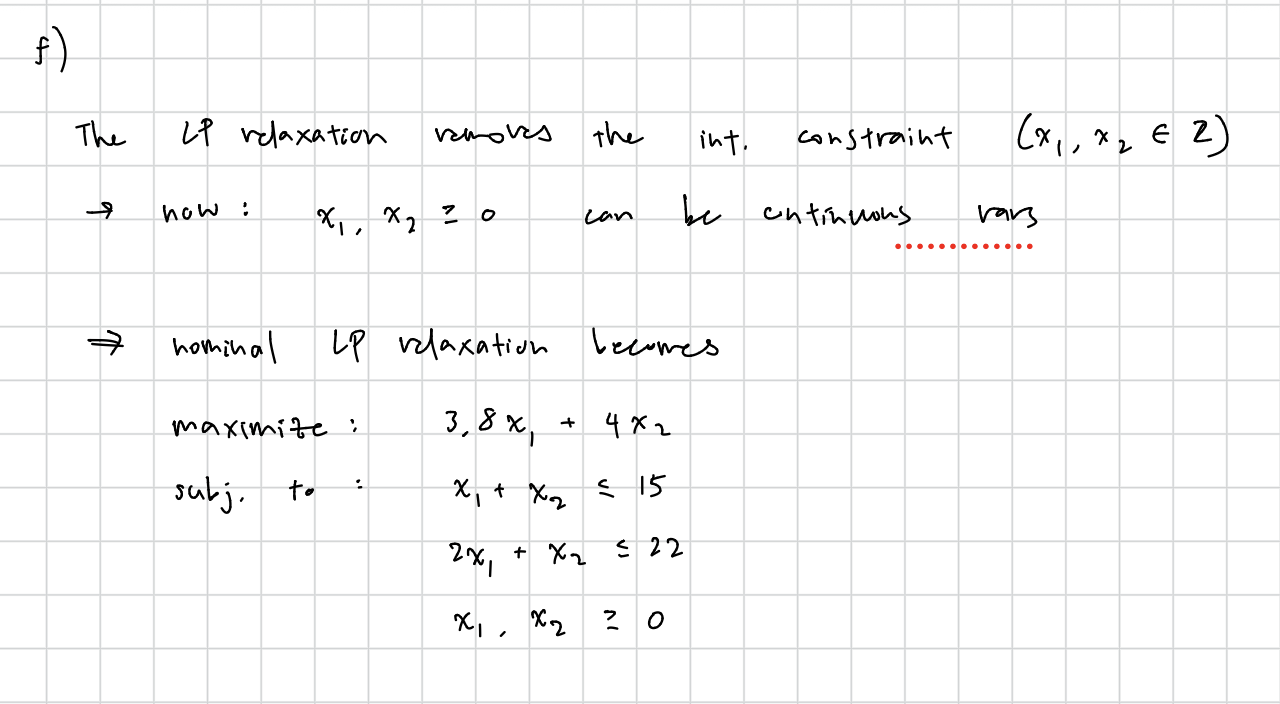

In [22]:
display(Image("3f.png", width=600))

In [23]:
import cvxpy as cp
import numpy as np

x_lp = cp.Variable(2)

objective = cp.Maximize(3.8*x_lp[0] + 4*x_lp[1])

constraints = [
    x_lp[0] + x_lp[1] <= 15,
    2*x_lp[0] + x_lp[1] <= 22,
    x_lp >= 0
]

prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCIPY)

print("Status:", prob.status)
print("LP relaxation optimal profit:", prob.value)
print("x:", x_lp.value)

Status: optimal
LP relaxation optimal profit: 60.0
x: [-0. 15.]


this is just the same integer solution as we got in part d. this is because the LP optimum is already at an integer vertex of the feasible region

so, relaxing the integer constraint has no effect and doesn't chance our solution